In [1]:
import requests
import pandas as pd

target = 1500         
page = 1
books = []

while True:
    url = f"https://openlibrary.org/search.json?q=subject:literature&page={page}"
    
    data = requests.get(url).json()
    docs = data["docs"]
    
    print(f"Page {page} → {len(docs)} records")

    books.extend(docs)
  
    if len(books) >= target:
        print("Reached the target of 1500 records. Stopping.")
        break

    page += 1

df = pd.json_normalize(books[:target])

df.to_csv("literature_books.csv", index=False, encoding="utf-8")

Page 1 → 100 records
Page 2 → 100 records
Page 3 → 100 records
Page 4 → 100 records
Page 5 → 100 records
Page 6 → 100 records
Page 7 → 100 records
Page 8 → 100 records
Page 9 → 100 records
Page 10 → 100 records
Page 11 → 100 records
Page 12 → 100 records
Page 13 → 100 records
Page 14 → 100 records
Page 15 → 100 records
Reached the target of 1500 records. Stopping.


| Column Name          | Description                                                           | Data Type      | Relevant for Analysis? |
| -------------------- | --------------------------------------------------------------------- | -------------- | ---------------------- |
| title                | The title of the book                                                 | string         | Yes                    |
| subtitle             | Subtitle of the book (94.33% NA)                                      | string         | No                     |
| author_name          | Name(s) of the author(s)                                              | list of string | Yes                    |
| author_key           | Unique identifier(s) for the author(s)                                | object         | Yes                    |
| first_publish_year   | Year of the book's first publication; may contain inconsistent values | float/int      | Yes                    |
| edition_count        | Number of editions; contains many outliers                            | int            | Yes                    |
| language             | Languages of the book                                                 | list of string | Yes                    |
| cover_i              | Numerical identifier of the book cover                                | int            | No                     |
| cover_edition_key    | Edition key associated with the cover (8.13% NA)                      | string         | No                     |
| ia                   | Internet Archive identifier (0.47% NA)                                | string         | No                     |
| ia_collection_s      | Internet Archive collection(s) (0.53% NA)                             | string         | No                     |
| lending_edition_s    | Edition key used for digital lending (10.27% NA)                      | string         | No                     |
| lending_identifier_s | Lending-related identifier (10.27% NA)                                | string         | No                     |
| has_fulltext         | Boolean flag indicating if the book has full text available           | bool           | Yes                    |
| public_scan_b        | Boolean value showing whether a public scan exists                    | bool           | Yes                    |
| ebook_access         | Indicates ebook access level (full, restricted, borrowable)           | string         | Yes                    |
| id_librivox          | Librivox audiobook ID (90.07% NA)                                     | string         | No                     |
| id_project_gutenberg | Project Gutenberg ID (84.87% NA)                                      | string         | No                     |
| id_standard_ebooks   | Standard ebooks ID (87.20% NA)                                        | string         | No                     |
| id_wikisource        | Wikisource ID or link (99.73% NA)                                     | string         | No                     |
| key                  | A unique identifier for each book entry                               | string         | Yes                    |



In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("literature_books.csv")

In [4]:
df.head()

,author_key,author_name,cover_i,ebook_access,edition_count,first_publish_year,has_fulltext,key,language,public_scan_b,...,cover_edition_key,ia,ia_collection_s,lending_edition_s,lending_identifier_s,id_project_gutenberg,subtitle,id_librivox,id_standard_ebooks,id_wikisource
0,"['OL244705A', 'OL2685786A', 'OL2685817A', 'OL7...","['M. H. Abrams', 'M. Abrams', 'M. H. Adams', '...",12483786,no_ebook,244,1962,False,/works/OL2026379W,['eng'],False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,['OL116513A'],['Lindley Murray'],7092218,public,118,1800,True,/works/OL1147650W,['eng'],True,...,OL20319860M,"['cihm_51441', 'kerneysabridgmen00murr', 'cihm...",additional_collections;americana;cdl;europeanl...,OL22110100M,cihm_51441,NaN,NaN,NaN,NaN,NaN
2,['OL19450A'],['Virginia Woolf'],119517,borrowable,255,1931,True,/works/OL39316W,"['hun', 'glg', 'spa', 'ita', 'fre', 'dut', 'en...",False,...,OL7384287M,"['hullamok0000wool', 'waves0000wool_z2q6', 'wa...",americana;americanuniversity-ol;barryuniversit...,OL19548884M,hullamok0000wool,NaN,NaN,NaN,NaN,NaN
3,['OL244097A'],['Howard Pyle'],5913135,public,724,1883,True,/works/OL2021953W,"['eng', 'tur', 'spa', 'rum', 'fre', 'ger']",True,...,OL7136095M,"['cu31924022499846', 'merryadventureso00pyleri...",americana;bpljordan-ol;cdl;cnusd-ol;cornell;de...,OL24179106M,cu31924022499846,NaN,NaN,NaN,NaN,NaN
4,['OL33146A'],['Franz Kafka'],12605605,public,166,1926,True,/works/OL498434W,"['eng', 'jpn', 'chi', 'spa', 'fre', 'gre', 'ge...",True,...,OL7461641M,"['castle01kafk', 'lechateau0000kafk_a9z6', 'da...",americana;americanuniversity-ol;claremont_scho...,OL26398835M,castle01kafk,NaN,NaN,NaN,NaN,NaN


In [5]:
df.tail()

,author_key,author_name,cover_i,ebook_access,edition_count,first_publish_year,has_fulltext,key,language,public_scan_b,...,cover_edition_key,ia,ia_collection_s,lending_edition_s,lending_identifier_s,id_project_gutenberg,subtitle,id_librivox,id_standard_ebooks,id_wikisource
1495,['OL21317A'],['Lois McMaster Bujold'],238000,printdisabled,31,1991,True,/works/OL56910W,"['fre', 'spa', 'rus', 'chi', 'eng', 'ger']",False,...,OL6788329M,"['lefleaudechalion0000macm', 'curseofchalion00...",americana;delawarecountydistrictlibrary;intern...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1496,['OL115914A'],['James Hervey'],9042942,public,94,1748,True,/works/OL1137831W,"['eng', 'fre']",True,...,NaN,"['meditationsconte00herv', 'MN41535ucmf_0', 'm...",Princeton;additional_collections;americana;blc...,OL17957997M,meditationsconte00herv,NaN,NaN,NaN,NaN,NaN
1497,"['OL24638A', 'OL113828A']","['Charles Dickens', 'Elizabeth Cleghorn Gaskell']",5664803,public,261,1859,True,/works/OL14869112W,"['ita', 'eng']",True,...,OL7186808M,"['hauntedhouseextr00dickrich', 'hauntedhouse00...",americana;americanuniversity-ol;binghamton-ol;...,OL7186808M,hauntedhouseextr00dickrich,NaN,NaN,NaN,NaN,NaN
1498,['OL3451319A'],['Christopher Marlowe'],10617924,public,91,1609,True,/works/OL45714W,"['eng', 'ger']",True,...,OL31935185M,"['tragicalhistoryo0000marl_x2c7', 'tragicalhis...",americana;binghamton-ol;claremont_school_of_th...,OL31935185M,tragicalhistoryo0000marl_x2c7,NaN,NaN,NaN,NaN,NaN
1499,['OL22028A'],['Mary Roberts Rinehart'],1531748,borrowable,195,1926,True,/works/OL137388W,"['fre', 'eng']",False,...,OL7977939M,"['bat00rine_0', 'bat00rine']",americana;delawarecountydistrictlibrary;inlibr...,OL18046772M,bat00rine_0,NaN,NaN,NaN,NaN,NaN


In [6]:
print(df.shape)

(1500, 21)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   author_key            1500 non-null   object
 1   author_name           1500 non-null   object
 2   cover_i               1500 non-null   int64 
 3   ebook_access          1500 non-null   object
 4   edition_count         1500 non-null   int64 
 5   first_publish_year    1500 non-null   int64 
 6   has_fulltext          1500 non-null   bool  
 7   key                   1500 non-null   object
 8   language              1500 non-null   object
 9   public_scan_b         1500 non-null   bool  
 10  title                 1500 non-null   object
 11  cover_edition_key     1378 non-null   object
 12  ia                    1493 non-null   object
 13  ia_collection_s       1492 non-null   object
 14  lending_edition_s     1345 non-null   object
 15  lending_identifier_s  1345 non-null   

In [8]:
for col in df.columns:
    print(f"Column {col}:")
    print(f"Number of unique values: {len(df[col].value_counts())}")
    print(f"Number of null values: {df[col].isnull().sum()}")
    print("------------------------------")

Column author_key:
Number of unique values: 807
Number of null values: 0
------------------------------
Column author_name:
Number of unique values: 808
Number of null values: 0
------------------------------
Column cover_i:
Number of unique values: 1500
Number of null values: 0
------------------------------
Column ebook_access:
Number of unique values: 5
Number of null values: 0
------------------------------
Column edition_count:
Number of unique values: 497
Number of null values: 0
------------------------------
Column first_publish_year:
Number of unique values: 333
Number of null values: 0
------------------------------
Column has_fulltext:
Number of unique values: 2
Number of null values: 0
------------------------------
Column key:
Number of unique values: 1500
Number of null values: 0
------------------------------
Column language:
Number of unique values: 1262
Number of null values: 0
------------------------------
Column public_scan_b:
Number of unique values: 2
Number of nu

In [9]:
duplicates = df.duplicated().sum()
print(f"Number of duplicates: {duplicates}")

Number of duplicates: 0


In [10]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
object_features = df.select_dtypes(include=['object']).columns.tolist()

In [11]:
numerical_features

['cover_i', 'edition_count', 'first_publish_year']

In [12]:
df.describe()

,cover_i,edition_count,first_publish_year
count,1.500000e+03,1500.000000,1500.000000
mean,7.292939e+06,228.454000,1896.660000
std,4.551698e+06,354.477923,135.999104
min,1.134200e+04,25.000000,0.000000
25%,3.032140e+06,55.000000,1872.000000
50%,8.236382e+06,104.000000,1931.500000
75%,1.061806e+07,250.000000,1979.000000
max,1.513011e+07,4036.000000,2021.000000


In [13]:
object_features

['author_key',
 'author_name',
 'ebook_access',
 'key',
 'language',
 'title',
 'cover_edition_key',
 'ia',
 'ia_collection_s',
 'lending_edition_s',
 'lending_identifier_s',
 'id_project_gutenberg',
 'subtitle',
 'id_librivox',
 'id_standard_ebooks',
 'id_wikisource']

In [14]:
categorical_features= []
for col in df.columns:
    if col not in numerical_features:  
        categorical_features.append(col)

print("Categorical features:", categorical_features)

Categorical features: ['author_key', 'author_name', 'ebook_access', 'has_fulltext', 'key', 'language', 'public_scan_b', 'title', 'cover_edition_key', 'ia', 'ia_collection_s', 'lending_edition_s', 'lending_identifier_s', 'id_project_gutenberg', 'subtitle', 'id_librivox', 'id_standard_ebooks', 'id_wikisource']


In [15]:
for col in categorical_features :
    df[col] = df[col].astype('category')

In [16]:
for col in categorical_features:
    print(f"Column {col}:")
    print(df[col].value_counts())
    print("------------------------------")

Column author_key:
author_key
['OL27695A']                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          71
['OL9388A']                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

Data Inspection Summary:

Missing values:

Columns like id_librivox, id_standard_ebooks, and id_wikisource have extremely high missing values (>85%), which need to be removed because it isnot relevant to analysis. subtitle need to be removed or filled depending on analysis
cover_edition_key, ia_collection_s, lending_identifier_s, and lending_edition_s have medium missing values (8–10%) .
Outliers:

edition_count contains very high values (some books have hundreds of editions), which may skew analyses if not handled.
Inconsistent data: first_publish_year may contain unusual or incorrect values (very old or future years) that need verification.

language and author_name are stored as lists, which may need standardization or one-hot encoding for certain analyses.
Irrelevant data:  cover_i , cover_edition_key,ia_collection_s,lending_identifier_s,lending_edition_s,id_librivox,id_project_gutenberg,id_standard_ebooks,id_wikisource These columns are irrelevant because they are mostly IDs, metadata, or extremely missing


Data Cleaning

In [17]:
df.drop(columns=['id_librivox', 'id_standard_ebooks','id_wikisource','subtitle','id_project_gutenberg'], inplace=True)


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   author_key            1500 non-null   category
 1   author_name           1500 non-null   category
 2   cover_i               1500 non-null   int64   
 3   ebook_access          1500 non-null   category
 4   edition_count         1500 non-null   int64   
 5   first_publish_year    1500 non-null   int64   
 6   has_fulltext          1500 non-null   category
 7   key                   1500 non-null   category
 8   language              1500 non-null   category
 9   public_scan_b         1500 non-null   category
 10  title                 1500 non-null   category
 11  cover_edition_key     1378 non-null   category
 12  ia                    1493 non-null   category
 13  ia_collection_s       1492 non-null   category
 14  lending_edition_s     1345 non-null   category
 15  lend

In [19]:
df.drop(columns=['ia_collection_s', 'lending_identifier_s', 'lending_edition_s','ia'], inplace=True, errors='ignore')


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   author_key          1500 non-null   category
 1   author_name         1500 non-null   category
 2   cover_i             1500 non-null   int64   
 3   ebook_access        1500 non-null   category
 4   edition_count       1500 non-null   int64   
 5   first_publish_year  1500 non-null   int64   
 6   has_fulltext        1500 non-null   category
 7   key                 1500 non-null   category
 8   language            1500 non-null   category
 9   public_scan_b       1500 non-null   category
 10  title               1500 non-null   category
 11  cover_edition_key   1378 non-null   category
dtypes: category(9), int64(3)
memory usage: 307.9 KB


In [21]:
df['cover_edition_key'] = df['cover_edition_key'].astype('object')
df['cover_edition_key']=df['cover_edition_key'].fillna('not available')
df['cover_edition_key'] = df['cover_edition_key'].astype('category')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   author_key          1500 non-null   category
 1   author_name         1500 non-null   category
 2   cover_i             1500 non-null   int64   
 3   ebook_access        1500 non-null   category
 4   edition_count       1500 non-null   int64   
 5   first_publish_year  1500 non-null   int64   
 6   has_fulltext        1500 non-null   category
 7   key                 1500 non-null   category
 8   language            1500 non-null   category
 9   public_scan_b       1500 non-null   category
 10  title               1500 non-null   category
 11  cover_edition_key   1500 non-null   category
dtypes: category(9), int64(3)
memory usage: 307.9 KB


In [23]:

unique_counts = df.nunique()
unique_counts.sort_values(ascending=False)



cover_i               1500
key                   1500
title                 1482
cover_edition_key     1379
language              1262
author_name            808
author_key             807
edition_count          497
first_publish_year     333
ebook_access             5
has_fulltext             2
public_scan_b            2
dtype: int64

In [24]:
for col in ['language', 'author_name']:
    df[col] = df[col].str.lower()

In [25]:
year_counts = df['first_publish_year'].value_counts().sort_index()
print(year_counts)

first_publish_year
0       2
1000    1
1200    1
1440    1
1467    1
       ..
2015    2
2016    3
2018    1
2019    1
2021    1
Name: count, Length: 333, dtype: int64


In [26]:
df.loc[
    (df['first_publish_year'] <= 0) |
    (df['first_publish_year'] > 2025) ,
    'first_publish_year'
] = np.nan

In [27]:
df['first_publish_year'] = df['first_publish_year'].fillna(df['first_publish_year'].median())


In [28]:
df["first_publish_year"] = df["first_publish_year"].astype(int)

In [29]:
df['first_publish_year'].value_counts().sort_index()

first_publish_year
1000    1
1200    1
1440    1
1467    1
1469    1
       ..
2015    2
2016    3
2018    1
2019    1
2021    1
Name: count, Length: 332, dtype: int64

In [30]:
print( df['first_publish_year'].nsmallest(10).values)
print( df['first_publish_year'].nlargest(10).values)

[1000 1200 1440 1467 1469 1470 1472 1476 1478 1479]
[2021 2019 2018 2016 2016 2016 2015 2015 2014 2014]


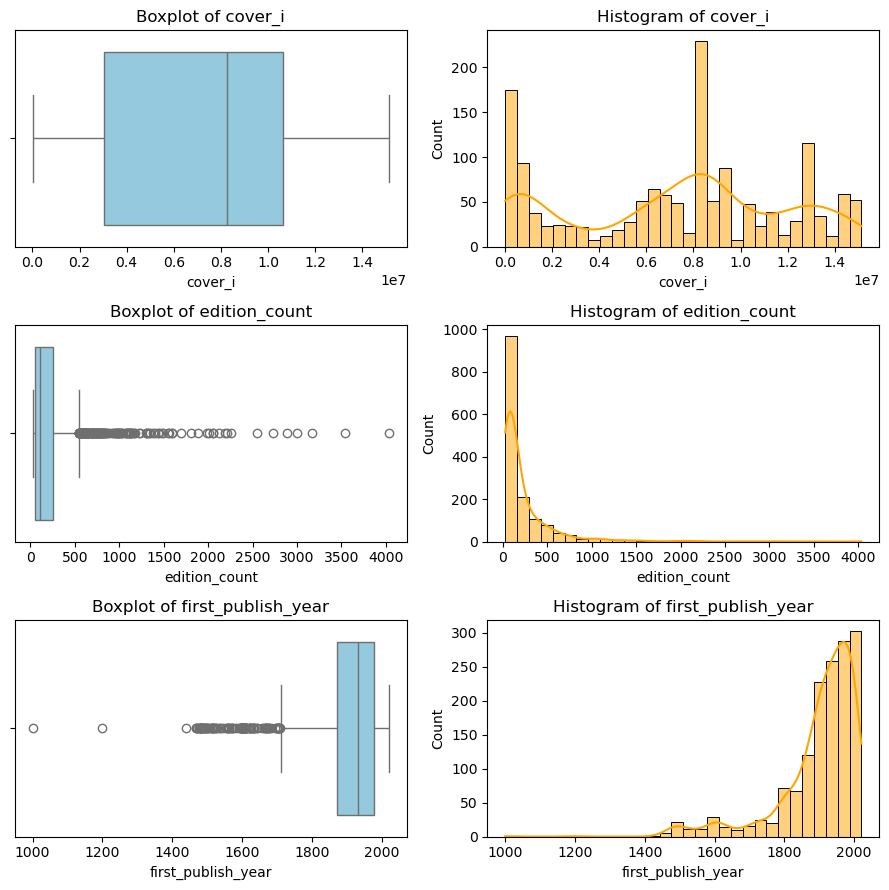

In [31]:
fig, axes = plt.subplots(len(numerical_features), 2, figsize=(9, 3 * len(numerical_features)))

for i, col in enumerate(numerical_features):
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Boxplot of {col}')
    # Histogram
    sns.histplot(df[col], bins=30, ax=axes[i, 1], kde=True, color='orange')
    axes[i, 1].set_title(f'Histogram of {col}')

plt.tight_layout()
plt.show()

In [32]:
Q1 = df['first_publish_year'].quantile(0.25)
Q3 = df['first_publish_year'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

year_outliers = df[(df['first_publish_year'] < lower_bound) | 
                   (df['first_publish_year'] > upper_bound)]


print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of publish year outliers:", year_outliers.shape[0])


Lower bound: 1711.5
Upper bound: 2139.5
Number of publish year outliers: 115


In [33]:
df= df[
    (df['first_publish_year'] >= lower_bound) &
    (df['first_publish_year'] <= upper_bound)
]


In [34]:
remaining_outliers = df[
    (df['first_publish_year'] < lower_bound) |
    (df['first_publish_year'] > upper_bound)
]

print("Number of outliers remaining after removal:", remaining_outliers.shape[0])

Number of outliers remaining after removal: 0


|**Although historical years are valid, outliers were removed to focus the analysis on the typical publishing range and avoid extreme values dominating visualizations and summary statistics.

In [35]:
df

,author_key,author_name,cover_i,ebook_access,edition_count,first_publish_year,has_fulltext,key,language,public_scan_b,title,cover_edition_key
0,"['OL244705A', 'OL2685786A', 'OL2685817A', 'OL7...","['m. h. abrams', 'm. abrams', 'm. h. adams', '...",12483786,no_ebook,244,1962,False,/works/OL2026379W,['eng'],False,The Norton Anthology of English Literature,not available
1,['OL116513A'],['lindley murray'],7092218,public,118,1800,True,/works/OL1147650W,['eng'],True,Abridgment of Murray's English Grammar,OL20319860M
2,['OL19450A'],['virginia woolf'],119517,borrowable,255,1931,True,/works/OL39316W,"['hun', 'glg', 'spa', 'ita', 'fre', 'dut', 'en...",False,The Waves,OL7384287M
3,['OL244097A'],['howard pyle'],5913135,public,724,1883,True,/works/OL2021953W,"['eng', 'tur', 'spa', 'rum', 'fre', 'ger']",True,Robin Hood,OL7136095M
4,['OL33146A'],['franz kafka'],12605605,public,166,1926,True,/works/OL498434W,"['eng', 'jpn', 'chi', 'spa', 'fre', 'gre', 'ge...",True,Das Schloß,OL7461641M
...,...,...,...,...,...,...,...,...,...,...,...,...
1494,['OL118077A'],['george orwell'],10524365,printdisabled,25,1978,True,/works/OL1167981W,"['spa', 'eng']",False,Animal Farm / Nineteen Eighty-Four,OL3672935M
1495,['OL21317A'],['lois mcmaster bujold'],238000,printdisabled,31,1991,True,/works/OL56910W,"['fre', 'spa', 'rus', 'chi', 'eng', 'ger']",False,The Curse of Chalion,OL6788329M
1496,['OL115914A'],['james hervey'],9042942,public,94,1748,True,/works/OL1137831W,"['eng', 'fre']",True,Meditations and contemplations,not available
1497,"['OL24638A', 'OL113828A']","['charles dickens', 'elizabeth cleghorn gaskell']",5664803,public,261,1859,True,/works/OL14869112W,"['ita', 'eng']",True,The Haunted House,OL7186808M


In [36]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [37]:
df[numerical_features].describe()

,cover_i,edition_count
count,1.385000e+03,1385.000000
mean,7.298231e+06,211.165343
std,4.648193e+06,338.455459
min,1.134200e+04,25.000000
25%,2.626880e+06,52.000000
50%,8.237030e+06,98.000000
75%,1.087078e+07,220.000000
max,1.513011e+07,4036.000000


In [38]:
Q1 = df['edition_count'].quantile(0.25)
Q3 = df['edition_count'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [39]:
mode_value = df['edition_count'].mode()[0]

In [40]:
df.loc[(df['edition_count'] < lower) | (df['edition_count'] > upper), 'edition_count'] = mode_value

In [41]:
remaining_outliers = df[
    (df['edition_count'] < lower) |
    (df['edition_count'] > upper)
]

print("Number of outliers remaining after removal:", remaining_outliers.shape[0])

Number of outliers remaining after removal: 0


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1385 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   author_key          1385 non-null   category
 1   author_name         1385 non-null   object  
 2   cover_i             1385 non-null   int64   
 3   ebook_access        1385 non-null   category
 4   edition_count       1385 non-null   int64   
 5   first_publish_year  1385 non-null   int32   
 6   has_fulltext        1385 non-null   category
 7   key                 1385 non-null   category
 8   language            1385 non-null   object  
 9   public_scan_b       1385 non-null   category
 10  title               1385 non-null   category
 11  cover_edition_key   1385 non-null   category
dtypes: category(7), int32(1), int64(2), object(2)
memory usage: 244.3+ KB


In [43]:
df.to_csv("literature_books.csv", index=False)

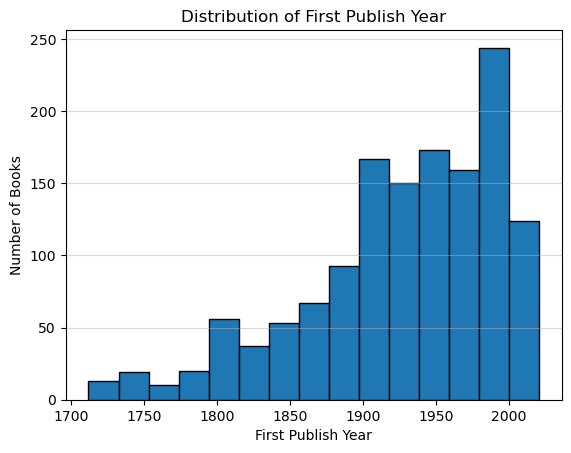

In [56]:
#Maryoma
plt.hist(df['first_publish_year'], bins=15, edgecolor='black')
plt.grid(axis='y', alpha=0.5)
plt.xlabel('First Publish Year')
plt.ylabel('Number of Books')
plt.title('Distribution of First Publish Year')
plt.show()

### "Roughly speaking, which era does our library focus on?"

**Frequency Histogram**. It is the most fundamental way to visualize the "shape" of your data. It takes all the publication years and groups them into buckets to show you when the bulk of your library was written.

---

### **1. What You Will See (Visual Elements)**
* **15 Blocky Bars:**
    * Unlike a bar chart (where every year has a bar), this histogram groups years together because of `bins=15`.
    * Each bar represents a **range of years** (e.g., one bar might cover 1900–1910).
    * **Height:** The taller the bar, the more books were published in that specific time range.
* **Black Borders (`edgecolor='black'`):**
    * Each blue bar has a crisp black outline. This is crucial because, without it, adjacent bars would blend into one big blue blob. The black lines separate the time periods clearly.
* **Horizontal Grid Lines:**
    * Faint lines across the background help your eye trace the top of a bar to the Y-axis number, so you can guess the count (e.g., "Ah, this bar reaches 150").

---

### **2. What You Will Understand (Insights)**
* **The "Weight" of History:**
    * You can instantly see where the "center of gravity" of your collection is.
    * If the tall bars are on the **left**, your library is historical.
    * If the tall bars are on the **right**, your library is contemporary.
* **Gaps and Spikes:**
    * **Spikes:** A very tall bar tells you there was a "publishing boom" in that era.
    * **Gaps:** If you see an empty space where a bar should be, it tells you that you have **zero** books from that period (e.g., a "missing century" in your data).

---

### **3. Technical & Code "Smartness"**
* **Simplicity (`bins=15`):**
    * The code forces the entire timeline into just **15 groups**.
    * **Why this matters:** If your data spans 500 years (1500–2000), plotting every single year would look like messy noise. Grouping them into 15 big chunks simplifies the view so you can see the **macro trend** rather than micro details.
* **Readability (`plt.grid`):**
    * `axis='y'`: The grid lines are only drawn horizontally. This is smart design—vertical grid lines would just clutter the chart and confuse the viewer.


It is a "quick diagnostic" tool. Before doing complex analysis, you look at this to make sure your data isn't completely broken or biased toward one random year.

first_publish_year
1899     9
1900    43
1901     6
1902     6
Name: count, dtype: int64


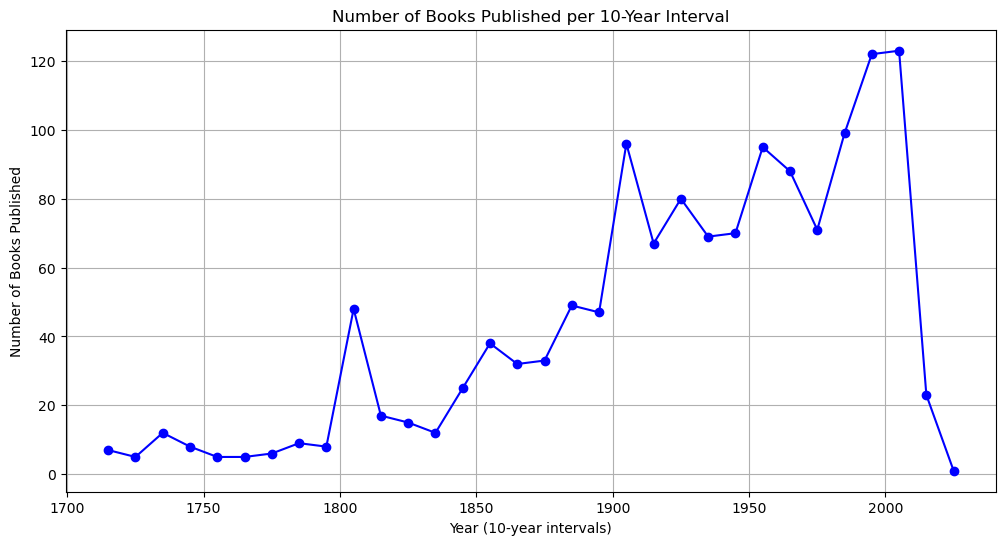

In [60]:
import matplotlib.pyplot as plt
import numpy as np

min_year = df['first_publish_year'].min()
max_year = df['first_publish_year'].max()

years_of_interest = [1899, 1900, 1901, 1902]
subset = df[df['first_publish_year'].isin(years_of_interest)]
print(subset['first_publish_year'].value_counts().sort_index())

bins = np.arange(min_year - (min_year % 10), max_year + 10, 10)

counts, edges = np.histogram(df['first_publish_year'], bins=bins)

bin_centers = edges[:-1] + 5  

plt.figure(figsize=(12,6))
plt.plot(bin_centers, counts, marker='o', linestyle='-', color='blue')
plt.xlabel('Year (10-year intervals)')
plt.ylabel('Number of Books Published')
plt.title('Number of Books Published per 10-Year Interval')
plt.grid(True)
plt.show()

 ### "Ignoring the yearly ups and downs, what is the smooth, long-term growth curve of our library?"
 
 **Line Chart of Decadal Trends**. Unlike a standard histogram that uses bars, this transforms the data into a smooth line connecting points. It groups your books into **10-year buckets** (decades) to show long-term growth patterns.

---

### **1. What You Will See (Visual Elements)**
* **A Connected Blue Line with Dots:**
    * **The Dots (`marker='o'`):** Each dot represents a specific decade (e.g., the 1950s). The height of the dot tells you how many books were published in that entire 10-year period.
    * **The Line (`linestyle='-'`):** Connects the dots to help your eye follow the path of history.
* **X-Axis (Time Intervals):**
    * Instead of showing every single year (1991, 1992, 1993), this simplifies time into chunks (1890, 1900, 1910).
* **Grid Lines:**
    * The grid helps you pinpoint the exact decade for every peak or valley in the line.

---

### **2. What You Will Understand (Insights)**
* **The "Big Picture" (Macro-Trends):**
    * This visualization removes the "noise."
    * In a normal yearly chart, a bad year (due to a paper shortage, for example) looks like a huge crash. In a decadal chart, that bad year gets averaged out with the 9 good years around it.
    * It answers: **"Is literature generally growing or shrinking over the centuries?"**
* **The "Rate of Change":**
    * By looking at the **slope** of the line, you can see speed.
    * **Steep Slope:** Rapid explosion in publishing (likely post-1950s).
    * **Flat Slope:** Stagnation or consistent output (likely pre-1800s).
* **Data Quality Check (The Console Output):**
    * **Why?** This is a manual "Sanity Check" to ensure the "turn of the century" data isn't missing. Sometimes databases have glitches when the year rolls over from '99 to '00.

---

### **3. Technical & Code "Smartness"**
* **The "Floor" Logic (`min_year - (min_year % 10)`):**
    * This is a brilliant piece of math.
    * If your first book is from **1857**, this math calculates `1857 - 7 = 1850`.
    * It automatically forces the chart to start at a nice, round number (1850) rather than a random awkward year.
* **Centering the Dots (`bin_centers = edges[:-1] + 5`):**
    * This is the subtle genius of the code.
    * When you bin years 1900–1910, standard code might put the dot at 1900 (the left edge).
 

---
It converts chaotic data into a clean, smooth narrative.

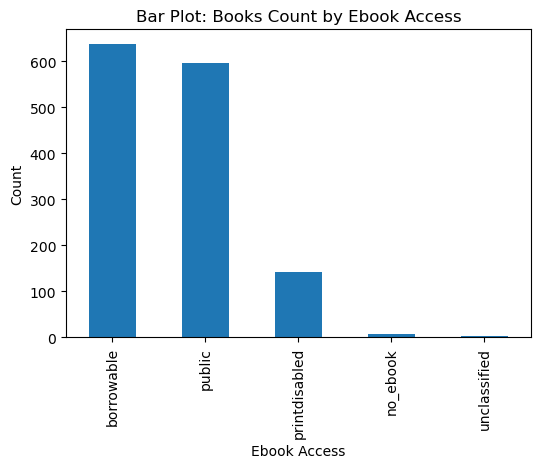

In [65]:
plt.figure(figsize=(6,4))

df['ebook_access'].value_counts().plot(kind='bar')
plt.xlabel('Ebook Access')
plt.ylabel('Count')

plt.title('Bar Plot: Books Count by Ebook Access')
plt.show()

 ### "What is the most common way users can access books in this library, and what are the raw numbers?"

standard **Vertical Bar Chart**. It counts how many books fall into each "Ebook Access" category. Unlike the Pie Chart (which shows percentages), this shows the **raw numbers** (magnitude).

---

### **1. What You Will See (Visual Elements)**
* **Vertical Bars:**
    * Each bar represents a specific status (e.g., "borrowable", "public", "no_ebook").
    * **Height:** The taller the bar, the more books fit that category.
* **Sorted Order:**
    * Because the code uses `.value_counts()`, the bars will automatically appear **sorted from tallest to shortest** (left to right). You will see the most common category first.
* **X-Axis (Bottom):** The names of the access types.
* **Y-Axis (Left):** The actual number of books (0, 500, 1000, etc.).

---

### **2. What You Will Understand (Insights)**
* **The "Dominant" Access Mode:**
    * You can instantly spot the "winner." If the first bar is "no_ebook", you know immediately that most of your library is offline/physical only.
* **Relative Scale:**
    * You can compare the difference visually. Is the "public" bar half the size of the "borrowable" bar? Or are they roughly equal?
* **Volume Analysis:**
    * Unlike a pie chart, this allows you to see the *total volume*. If the tallest bar only goes up to 10 on the Y-axis, your dataset is tiny. If it goes to 10,000, your dataset is huge.

---

### **3. Technical & Code "Smartness"**
* **The Power of `value_counts()`:**
    * This single function does two jobs:
        1.  **Counts:** It calculates the frequency of each category.
        2.  **Sorts:** It automatically arranges them from highest to lowest. This makes the chart readable instantly without extra code to sort it manually.
* **Simplicity (`kind='bar'`):**
    * This uses the built-in plotting capability of pandas (`df.plot`). It is faster and simpler to write than using Seaborn for quick checks.


It gives you the **"inventory count"** of your digital assets.

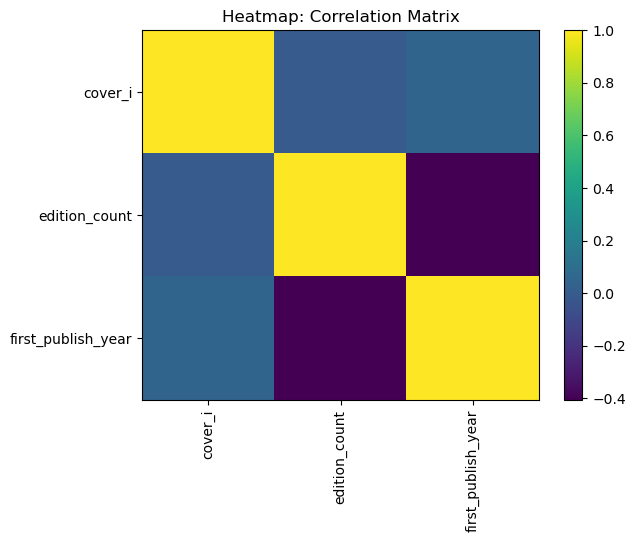

                     cover_i  edition_count  first_publish_year
cover_i             1.000000      -0.002256            0.049206
edition_count      -0.002256       1.000000           -0.405739
first_publish_year  0.049206      -0.405739            1.000000


In [47]:
corr_matrix = df.corr(numeric_only=True)

plt.figure()
plt.imshow(corr_matrix, aspect='auto')
plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix)), corr_matrix.columns)
plt.colorbar()
plt.title('Heatmap: Correlation Matrix')
plt.show()
print(corr_matrix)

### ;)

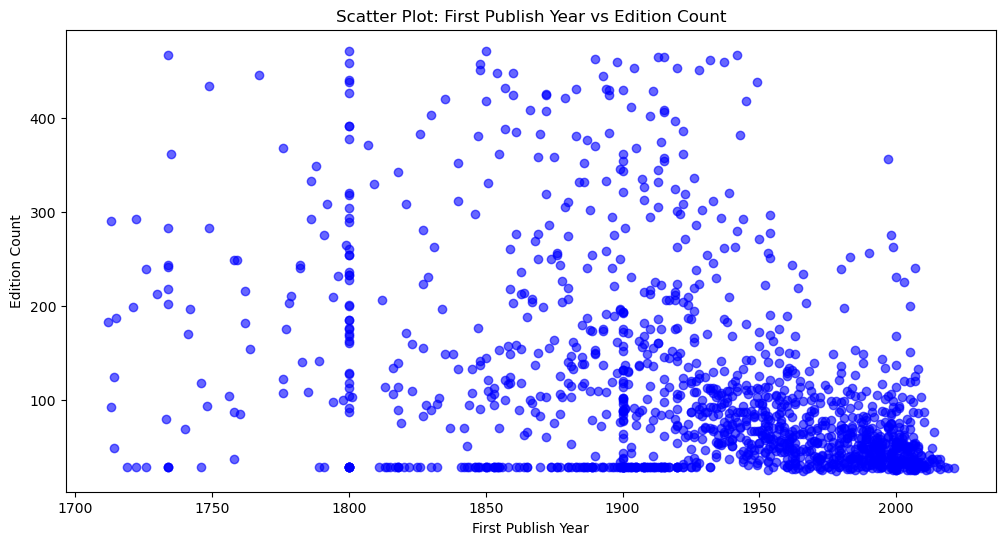

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.scatter(df['first_publish_year'], df['edition_count'], alpha=0.6, color='blue')
plt.xlabel('First Publish Year')
plt.ylabel('Edition Count')
plt.title('Scatter Plot: First Publish Year vs Edition Count')
plt.show()

   ### "Does the age of a book determine how many times it gets reprinted?"

 **Scatter Plot**. It is the standard scientific way to test if two variables are related to each other. Here, it tests the relationship between **Time** (Year) and **Popularity** (Edition Count).

---

### **1. What You Will See (Visual Elements)**
* **A Field of Blue Dots:**
    * Every single blue dot represents **one unique book** in your library.
    * If you have 1,000 books, you will see 1,000 dots.
* **The Position of the Dots:**
    * **Horizontal (Left/Right):** Represents the **Age**. Dots on the left are old books (e.g., 1850); dots on the right are new books (e.g., 2023).
    * **Vertical (Up/Down):** Represents **Popularity**. Dots high up have been reprinted many times (Bestsellers/Classics). Dots near the bottom have only been printed once or twice.
* **transparency (The "Ghost" Effect):**
    * Because of `alpha=0.6`, the dots are semi-transparent. If you see a dark, solid blue blob, it means many dots are piled on top of each other in that exact spot.

---

### **2. What You Will Understand (Insights)**
* **The "Test of Time" Hypothesis:**
    * You are looking for a pattern. **Do older books have more editions?**
    * **Scenario A (Positive Correlation):** If the dots drift upwards as you look to the left (older years), it proves that "Classics survive." Books like *Shakespeare* or *Austen* accumulate editions over centuries.
    * **Scenario B (No Correlation):** If the dots are scattered randomly everywhere, it means age doesn't guarantee popularity.
* **Spotting the "Superstars" (Outliers):**
    * Look for the lonely dots that are **very high up**.
    * If you see a dot high up on the **right side** (recent year, high editions), that is a modern viral sensation (e.g., *Harry Potter* or *The Hunger Games*).
    * If you see a dot high up on the **left side**, that is a literary canon classic (e.g., *The Iliad*).
* **The "Long Tail":**
    * You will likely see a thick carpet of blue dots hugging the bottom of the chart. This tells you that the **vast majority** of books are only published once and never reprinted.

---

### **3. Technical & Code "Smartness"**
* **Handling Overplotting (`alpha=0.6`):**
    * This is the most important technical decision in this code.
    * Without `alpha`, 100 books published in 1990 with 1 edition would look like a single dot. With `alpha`, they look like a darker, denser cluster. It allows you to see **density**, not just position.
* **Figure Size (`12,6`):**
    * The wide aspect ratio helps spread out the years (X-axis) so the timeline doesn't look squashed.

---


It allows you to separate the "One-Hit Wonders" from the "Timeless Classics."

In [ ]:
import matplotlib.pyplot as plt

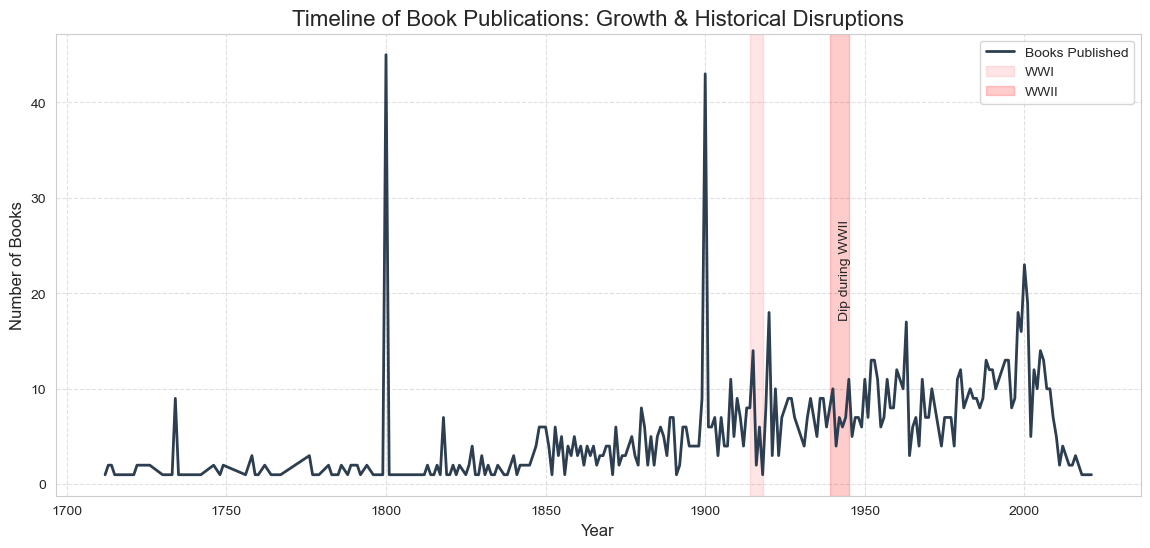

In [108]:
#Malak
yearly_counts = df['first_publish_year'].value_counts().sort_index()
plt.figure(figsize=(14, 6))
plt.plot(yearly_counts.index, yearly_counts.values, color='#2c3e50', linewidth=2, label='Books Published')
plt.axvspan(1914, 1918, color='red', alpha=0.1, label='WWI')
plt.axvspan(1939, 1945, color='red', alpha=0.2, label='WWII')
plt.title('Timeline of Book Publications: Growth & Historical Disruptions', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Books', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.text(1942, yearly_counts.max()/2, 'Dip during WWII', rotation=90, verticalalignment='center')
plt.show()

   ### "How did major global historical events (WWI & WWII) impact the output of literature in our collection?"
**Time Series Line Chart** overlaid with **Historical Annotations**. It doesn't just show data; it contextualizes it against real-world history (World War I and II) to see how global events affected literature.

---

### **1. What You Will See (Visual Elements)**
* **The Dark Line (`#2c3e50`):**
    * This jagged line travels from left (past) to right (present).
    * It shows the **volume** of books published each year. If the line goes up, the library is growing. If it goes down, fewer books were published.
* **The Red Shaded Zones (The "Danger" Zones):**
    * You will see two vertical bands of light red color background.
    * **First Band (Light Red):** Covers 1914–1918 (World War I).
    * **Second Band (Darker Red):** Covers 1939–1945 (World War II).
* **Text Annotation:**
    * Inside the WWII zone, there is vertical text saying **"Dip during WWII"**. This explicitly points out a drop in the line during those years.

---

### **2. What You Will Understand (Insights)**
* **The "War Effect":**
    * You can visually test the hypothesis: *Does war stop art?*
    * If the black line **dips** (goes down) inside the red zones, it proves that the wars disrupted the publishing industry (shortage of paper, authors fighting, bombed libraries).
    * If the line stays flat or goes up, it suggests the collection is resilient or perhaps contains war propaganda/history books published *during* the war.
* **Post-War Booms:**
    * Look at the years immediately *after* the red zones (e.g., 1946–1950). You often see a sharp spike upwards. This represents the "Baby Boom" era of literature—a recovery period where culture flourished again.
* **General Growth:**
    * Ignoring the wars, does the line generally trend upwards? This indicates the natural expansion of the publishing industry and literacy over the last century.

---

### **3. Technical & Code "Smartness"**
* **Contextual Shading (`plt.axvspan`):**
    * This is the star of the show. `axvspan` stands for **"Axis Vertical Span"**.
    * Instead of just drawing a line, the code highlights a specific *period* of time across the entire background. This is a pro-level data storytelling technique to highlight "Eras" rather than single moments.
* **Transparency (`alpha=0.1` vs `0.2`):**
    * The code sets WWI to `alpha=0.1` (very faint) and WWII to `alpha=0.2` (slightly darker). This subtle visual cue suggests that WWII might have had a more intense or recent impact, or simply helps distinguish the two events.



It transforms your project from a simple "Data Analysis" into a "Digital Humanities" study, linking code to history.

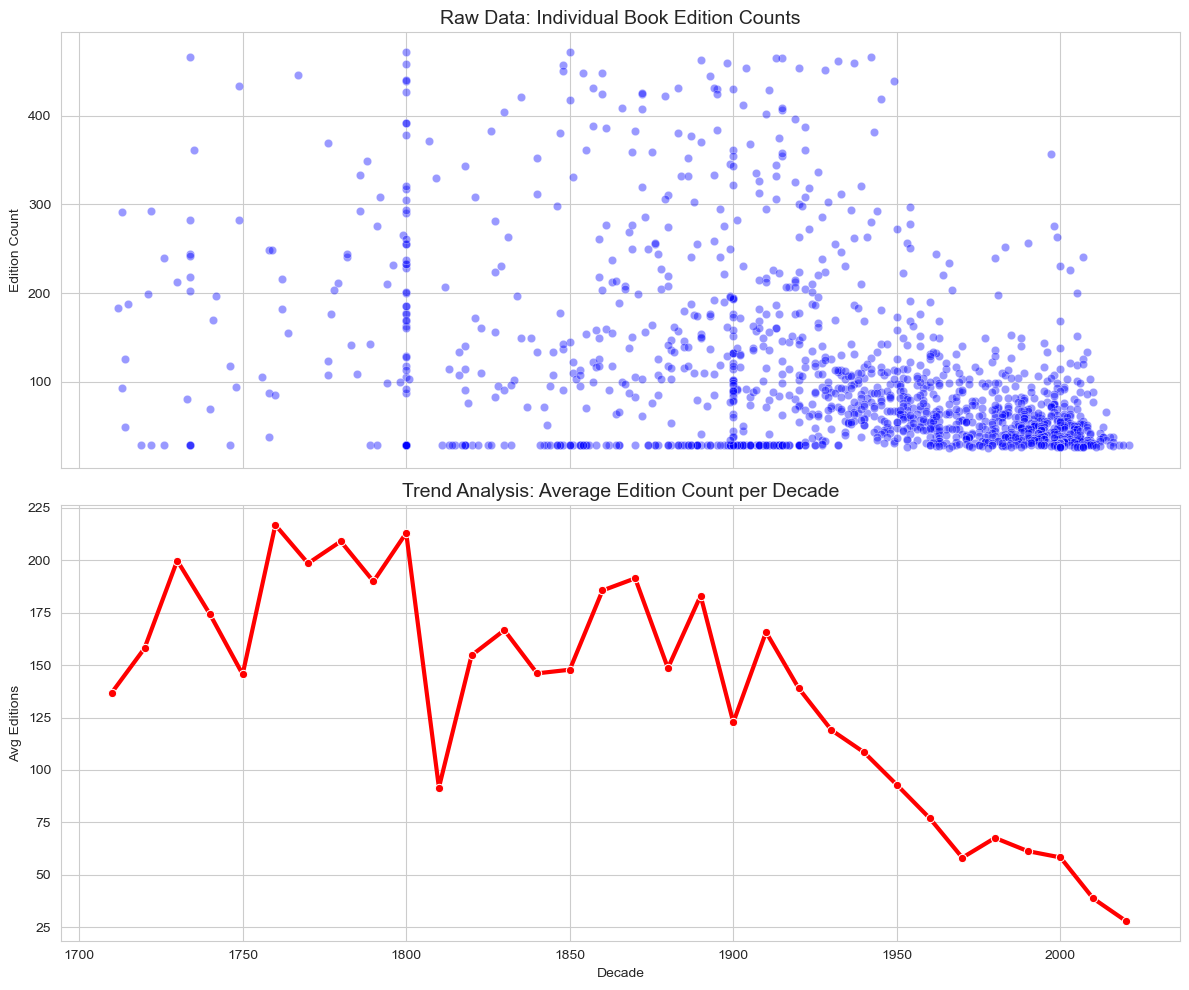

In [93]:
import seaborn as sns
df['decade'] = (df['first_publish_year'] // 10 * 10).astype(int)
decade_stats = df.groupby('decade')['edition_count'].mean().reset_index()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
sns.scatterplot(data=df, x='first_publish_year', y='edition_count', alpha=0.4, color='blue', ax=ax1)
ax1.set_title('Raw Data: Individual Book Edition Counts', fontsize=14)
ax1.set_ylabel('Edition Count')
sns.lineplot(data=decade_stats, x='decade', y='edition_count', color='red', linewidth=3, marker='o', ax=ax2)
ax2.set_title('Trend Analysis: Average Edition Count per Decade', fontsize=14)
ax2.set_ylabel('Avg Editions')
ax2.set_xlabel('Decade')
ax2.grid(True)

plt.tight_layout()
plt.show()

  ### "Does the age of a book correlate with its popularity (edition count), and can we see the general trend despite the outliers?"
**Multi-Panel Chart** (two charts stacked on top of each other) to separate "Noise" from "Signal."
* **Top Chart:** Shows the raw, messy reality of individual books.
* **Bottom Chart:** Shows the clear, smoothed-out trend over time.

---

### **1. What You Will See (Visual Elements)**

#### **Top Chart: "Raw Data" (The Blue Scatter)**
* **A Cloud of Blue Dots:** Each dot represents **one specific book**.
* **Position:**
    * **X-axis:** When the book was published.
    * **Y-axis:** How many editions it has.
* **What it looks like:** You will likely see a dense cluster of dots near the bottom (books with 1-5 editions) and a few random dots floating way up high (bestsellers/classics with 100+ editions).

#### **Bottom Chart: "Trend Analysis" (The Red Line)**
* **A Thick Red Line:** This line connects the **averages** for each decade.
* **Markers (Circles):** Each circle represents the average performance of *all* books published in that 10-year period.
* **Grid:** The background grid helps you easily trace a specific decade to its average value.

---

### **2. What You Will Understand (Insights)**

* **The "Classic" Effect:**
    * You will probably see the red line start **high** on the left (1800s/1900s) and drop lower as it moves to the right (2000s).
    * **Why?** Older books (Classics like *Dickens* or *Austen*) have had 100+ years to be reprinted. New books haven't had enough time to accumulate editions yet.
* **Spotting Outliers (The "Viral" Hits):**
    * By comparing the Top Chart to the Bottom Chart, you can spot anomalies.
    * If the Red Line (average) is low for the 1990s, but you see **one huge blue dot** high up in the Top Chart for 1997, that’s *Harry Potter*. It tells you: "Most books from the 90s are forgotten, but this one is a superstar."
* **Smoothing the Noise:**
    * The raw data (Top) is chaotic and hard to read. The trend line (Bottom) answers the question: *"Generally speaking, were books from the 1920s more popular/reprinted than books from the 1980s?"*

---

### **3. Technical & Code "Smartness"**

* **Data Aggregation (The Logic):**
    * `df['decade'] = ... // 10 * 10`: This is a clever mathematical trick to turn a year like `1987` into `1980`. It buckets years into decades automatically.
    * `.groupby('decade')...mean()`: This calculates the average, filtering out the chaos of individual data points to find the underlying pattern.
* **Shared Axis (`sharex=True`):**
    * The code uses `sharex=True`. This ensures that both charts line up perfectly vertically. If you look at 1950 on the top chart, 1950 on the bottom chart is exactly underneath it. This makes comparing them intuitive.

It teaches the viewer the difference between **individual performance** (a specific book) and **generational performance** (an era of literature).

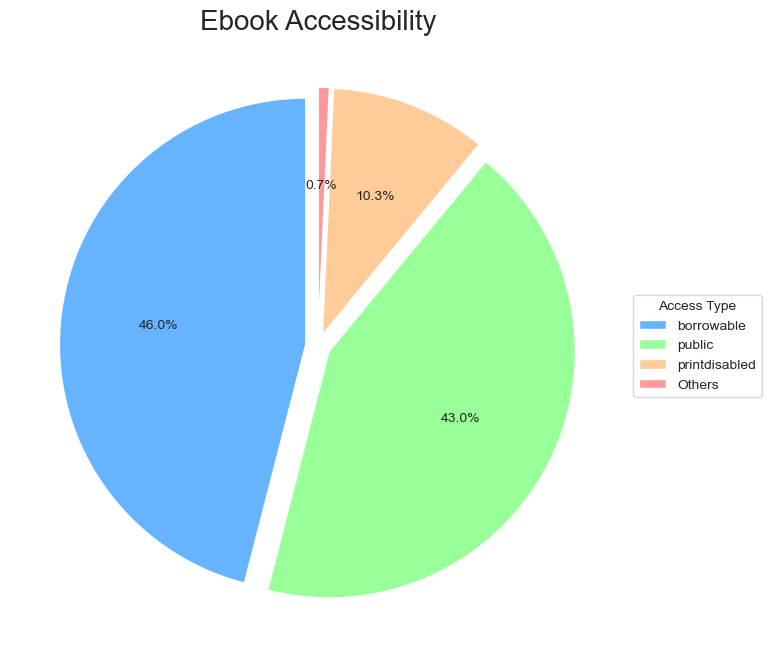

In [86]:
import matplotlib.pyplot as plt
counts = df['ebook_access'].value_counts()
threshold = 0.02 * counts.sum()
main_categories = counts[counts >= threshold]
small_categories = counts[counts < threshold]
if not small_categories.empty:
    main_categories['Others'] = small_categories.sum()

colors = ['#66b3ff', '#99ff99', '#ffcc99', '#ff9999', '#c2c2f0']

plt.figure(figsize=(12, 8))

wedges, texts, autotexts = plt.pie(main_categories, 
                                   autopct='%1.1f%%', 
                                   startangle=90, 
                                   colors=colors,
                                   explode=[0.05] * len(main_categories))
for text in texts:
    text.set_text("")

plt.legend(wedges, main_categories.index,
          title="Access Type",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.title('Ebook Accessibility', fontsize=20)
plt.show()

   ### "What percentage of our library is actually readable vs. just listed?"
   **Pie Chart** that breaks down the "Accessibility" of your library. It answers the fundamental question: *In what format are these books available to the public?*

---

### **1. What You Will See (Visual Elements)**
* **A "Clean" Pie:**
    * You will see a circle divided into colored slices.
    * **Percentages:** Inside each slice, you will see a number (e.g., **"45.2%"**).
    * **No Clutter:** Unlike messy pie charts that have text writing all over them, this code intentionally hides the text on the slices (`text.set_text("")`) to keep it looking modern.
* **"Exploded" Slices:**
    * The slices are slightly pulled apart from each other (`explode=[0.05]`). This gives the chart a "cut pizza" look, which makes it easier for the eye to distinguish between the different sections.
* **A Side Legend:**
    * Since the text was removed from the pie, a clear box on the right tells you what each color means (e.g., Blue = Public, Green = Borrowable).

---

### **2. What You Will Understand (Insights)**
* **The "Usability" of the Library:**
    * **Public (Free):** If this slice is big, your library is a goldmine for free researchers.
    * **Borrowable (Login required):** If this is big, it's a modern digital lending library.
    * **No Ebook / Print Disabled:** If this slice is the biggest, it means your dataset is mostly a "catalog" (metadata) rather than a "content repository" (actual books to read).
* **The "Availability" Ratio:**
    * You can instantly say: "Over 60% of our collection is fully readable right now," or "Only 10% of our books are digital." This is a key metric for stakeholders.

---

### **3. Technical & Code "Smartness"**
* **The "Others" Grouping (The Smartest Part):**
    * The code includes a sophisticated filter: `threshold = 0.02 * counts.sum()`.
    * **What it does:** It checks if a category is tiny (less than 2% of the total). If it is, it dumps it into a generic "Others" category.
    * **Why this matters:** Without this, your pie chart would have tiny, unreadable slivers that look like dirt. This ensures the chart remains professional and significant.
* **Custom Legend Positioning:**
    * `bbox_to_anchor=(1, 0, 0.5, 1)`: This specific coordinate system forces the legend to sit **outside** the chart. This prevents the common problem of the legend box covering up the actual data.


It transforms the abstract concept of "Access" into a concrete percentage distribution.

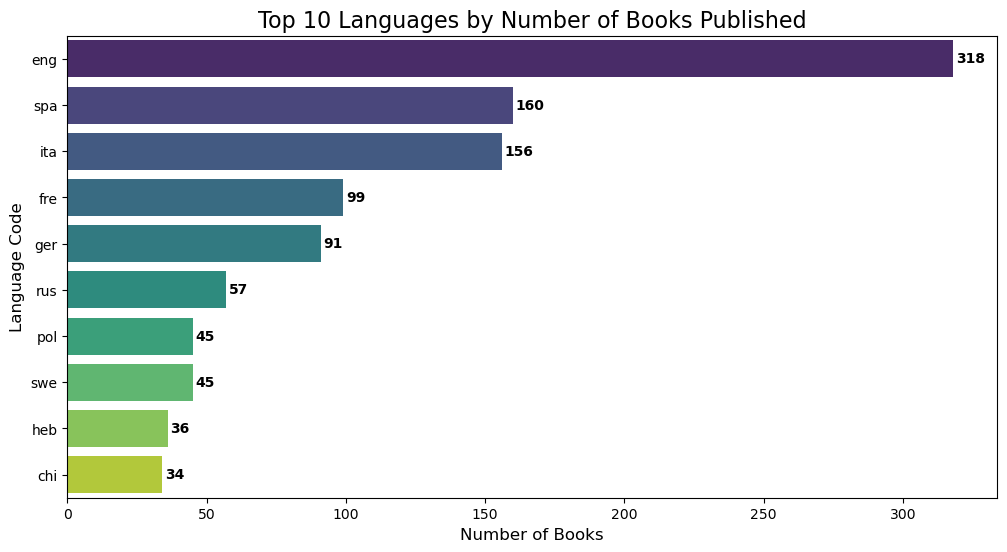

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_languages.values, 
    y=top_languages.index, 
    hue=top_languages.index, 
    palette='viridis', 
    legend=False              
)

plt.title('Top 10 Languages by Number of Books Published', fontsize=16)
plt.xlabel('Number of Books', fontsize=12)
plt.ylabel('Language Code', fontsize=12)

for i, v in enumerate(top_languages.values):
    plt.text(v + 1, i, str(v), color='black', va='center', fontweight='bold')

plt.show()

### "Is our collection linguistically diverse, or dominated by a single language?"

 **Horizontal Bar Chart** that ranks the top languages in your library. Instead of just listing them, it visually compares how many books are written in each language.


### **1. What You Will See (Visual Elements)**
* **Horizontal Bars:**
    * Each bar represents a language (e.g., 'eng' for English, 'fre' for French).
    * **Length:** The longer the bar, the more books you have in that language.
* **Color Gradient (`viridis`):**
    * The bars are colored using the "viridis" palette, which usually transitions from yellow/green to dark blue/purple. This helps distinct bars stand out visually.
* **Numbers at the End:**
    * Right next to each bar, there is a bold number (e.g., **150**). This shows the exact count, so you don't have to guess by looking at the bottom axis.

---

### **2. What You Will Understand (Insights)**
* **Language Dominance:**
    * You will instantly see which language is the "primary" one. Usually, in Open Library datasets, **English ('eng')** is the massive bar at the top.
* **Diversity Check:**
    * You can see how "international" your collection is. Are there 9 tiny bars for other languages, or are they significant? It reveals if your library is monolingual or multilingual.
* **Data Cleaning Needs:**
    * If you see codes like **'und'** (Undetermined) or **'mul'** (Multiple languages) in the top 10, it tells you that some metadata is vague and might need specific checking.

---

### **3. Technical & Code "Smartness"**
* **Exact Values (`plt.text` loop):**
    * The code includes a smart loop: `for i, v in enumerate...`.
    * **Why this matters:** In standard charts, it's hard to tell if a bar represents 48 or 52. This code forces Python to write the *exact number* (`str(v)`) right next to the bar, making the chart precise and scientific.
* **Horizontal Layout (`x=values, y=index`):**
    * The code puts languages on the vertical axis (`y=top_languages.index`).
    * **Why this matters:** Language codes or names are often long. If this were a vertical bar chart, the text would overlap and be unreadable. A horizontal layout is the professional standard for category labels.


It gives you a demographic profile of your books' languages in seconds.

In [80]:
!pip install wordcloud

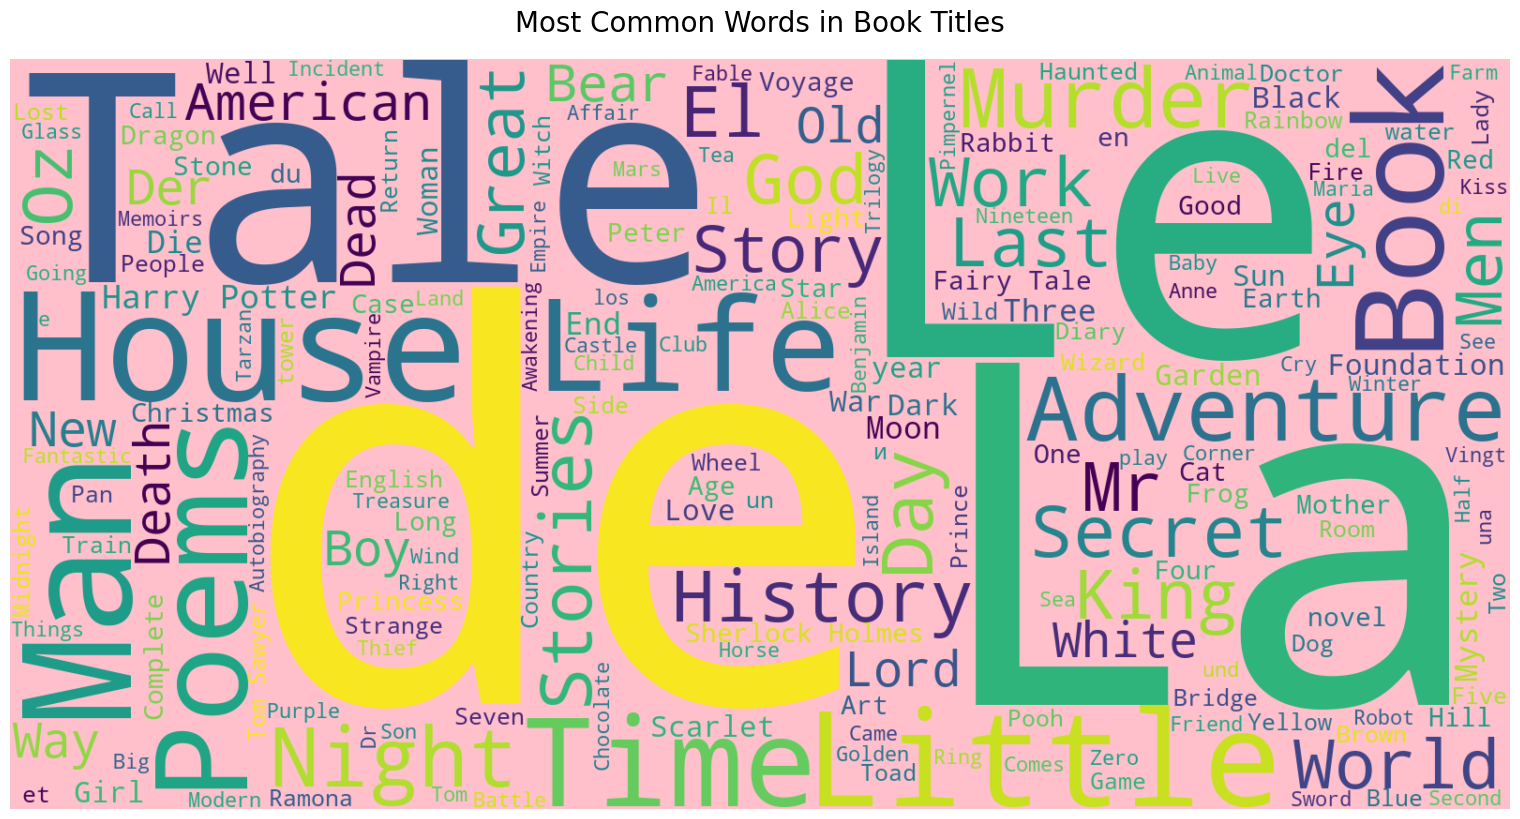

In [82]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

text_data = " ".join(title for title in df['title'].astype(str))

stopwords = set(STOPWORDS)

word_cloud = WordCloud(
    width=1600, 
    height=800,
    background_color='pink', 
    colormap='viridis',       
    stopwords=stopwords,
    min_font_size=10,
    max_words=200            
).generate(text_data)

plt.figure(figsize=(15, 8), facecolor=None)
plt.imshow(word_cloud, interpolation='bilinear')
plt.axis("off") 
plt.title('Most Common Words in Book Titles', fontsize=20, pad=20)
plt.tight_layout(pad=0)

plt.show()

   ### "What are the dominant themes and topics in our library's titles?"
   *Word Cloud* (also known as a Tag Cloud). It is a visual representation of text data where the size of each word corresponds to its frequency or importance in the dataset.

1. What You Will See (Visual Elements)
A "Cloud" of Words: You will see a chaotic but artistic cluster of words floating on a pink background.

Size Matters: Some words will be huge, while others will be tiny.

Big Words: These appear most often in your book titles.

Small Words: These appear less frequently but are still common enough to make the top 200 list.

Color Palette: The words will be colored in shades of blue, green, and purple (because of colormap='viridis'), which contrasts against the pink background.

2. What You Will Understand (Insights)
The "Flavor" of Your Library:

At a single glance, you can determine the genre or theme of the collection.

If the biggest words are "History", "War", "Life", you have a serious/non-fiction collection.

If the biggest words are "Mystery", "Love", "Dead", you have a fiction/novel-heavy collection.

If the biggest words are "Vol", "Index", "Report", your data might be "dirty" (containing technical documents instead of real book titles).

Keyword Dominance:

It tells you what keywords authors in this dataset love to use. It reveals the vocabulary of the specific era or genre you scraped.

3. Technical & Code "Smartness"
Noise Filtering (STOPWORDS):

The code uses STOPWORDS to automatically remove boring words like "the", "and", "is", "of". Without this, your biggest word would almost certainly be "The", which tells you nothing. This ensures only meaningful words are shown.

Aesthetic Customization:

background_color='pink': Sets a specific vibe (playful/distinct).

max_words=200: Limits the chaos. instead of showing thousands of words, it only picks the top 200 most frequent ones, keeping the image readable.

interpolation='bilinear': This creates a smoother image, so the text edges don't look pixelated or jagged.

It is a qualitative summary tool. While the histograms gave you numbers (dates, counts), this gives you context (words, meaning).

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

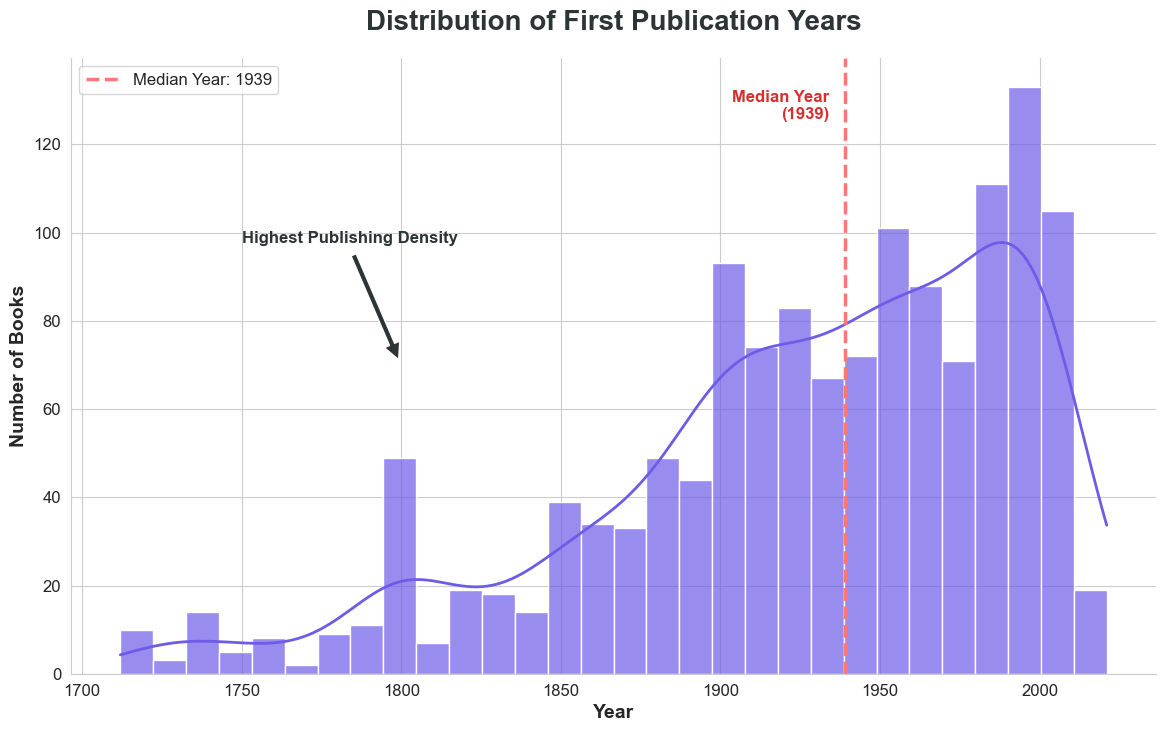

In [84]:
sns.set_style("whitegrid")
plt.figure(figsize=(14, 8))

ax = sns.histplot(data=df, x='first_publish_year', 
                  bins=30, 
                  kde=True, 
                  color='#6c5ce7', 
                  edgecolor='white',
                  alpha=0.7,
                  line_kws={'linewidth': 2})


median_year = df['first_publish_year'].median()
peak_year = df['first_publish_year'].mode()[0] 

plt.axvline(median_year, color='#ff7675', linestyle='--', linewidth=2.5, label=f'Median Year: {int(median_year)}')

plt.text(median_year - 5, ax.get_ylim()[1]*0.9, 
         f'Median Year\n({int(median_year)})', 
         color='#d63031', fontsize=12, fontweight='bold', ha='right')

plt.annotate('Highest Publishing Density', 
             xy=(peak_year, ax.get_ylim()[1]*0.5), 
             xytext=(peak_year - 50, ax.get_ylim()[1]*0.7), 
             arrowprops=dict(facecolor='#2d3436', shrink=0.05),
             fontsize=12, fontweight='bold', color='#2d3436')


plt.title('Distribution of First Publication Years', fontsize=20, fontweight='bold', pad=20, color='#2d3436')
plt.xlabel('Year', fontsize=14, fontweight='bold')
plt.ylabel('Number of Books', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, loc='upper left')
sns.despine()

plt.show()

   ### "When was the 'Golden Age' of this collection?"
a Distribution Histogram combined with a Density Curve (KDE). It visualizes the timeline of your library, showing when the books in your dataset were first published. It is a "Time Machine" view of your data.

### 1. What You Will See (Visual Elements)
Purple Bars (The Histogram):

These represent the volume of books published in specific time periods (bins).

Taller bars = More books published in those years.

Smooth Curve (The KDE Line):

The line sweeping over the bars represents the "trend." It smoothes out the jagged edges of the bars to show the general shape of the distribution.

Red Dashed Line (The Median):

A vertical marker that cuts your dataset exactly in half.

Meaning: 50% of your books are older than this year, and 50% are newer.

Annotation with Arrow ("Highest Publishing Density"):

An arrow pointing to the specific year (or era) where the most books were published.

### 2. What You Will Understand
The "Age" of Your Library:

You can instantly tell if your collection is "Classic" (skewed to the left, 1800s-1900s) or "Modern" (skewed to the right, 2000s).

Publishing Booms:

The arrow pointing to the "Highest Publishing Density" identifies the "Golden Era" of your specific dataset. For example, if it points to 1920, it suggests a focus on post-WWI literature.

Data Completeness:

If you see bars in years like "1000" or "2050", you instantly know you have outliers or data errors (bad metadata) that need cleaning.

The "Median" vs. "Average" (Why Median matters):

The code highlights the Median, which is smarter than the Average for dates. If you have one book from the year 1500, it would drag the "Average" down misleadingly. The Median is robust and gives you the "true middle" of your collection's timeline.

### Why is this important?
This visualization answers the question: "Is this a library of history, or a library of today?" It helps you profile the temporal nature of your dataset in a single glance.

In [94]:
pip install matplotlib-venn

Note: you may need to restart the kernel to use updated packages.


In [95]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import ast

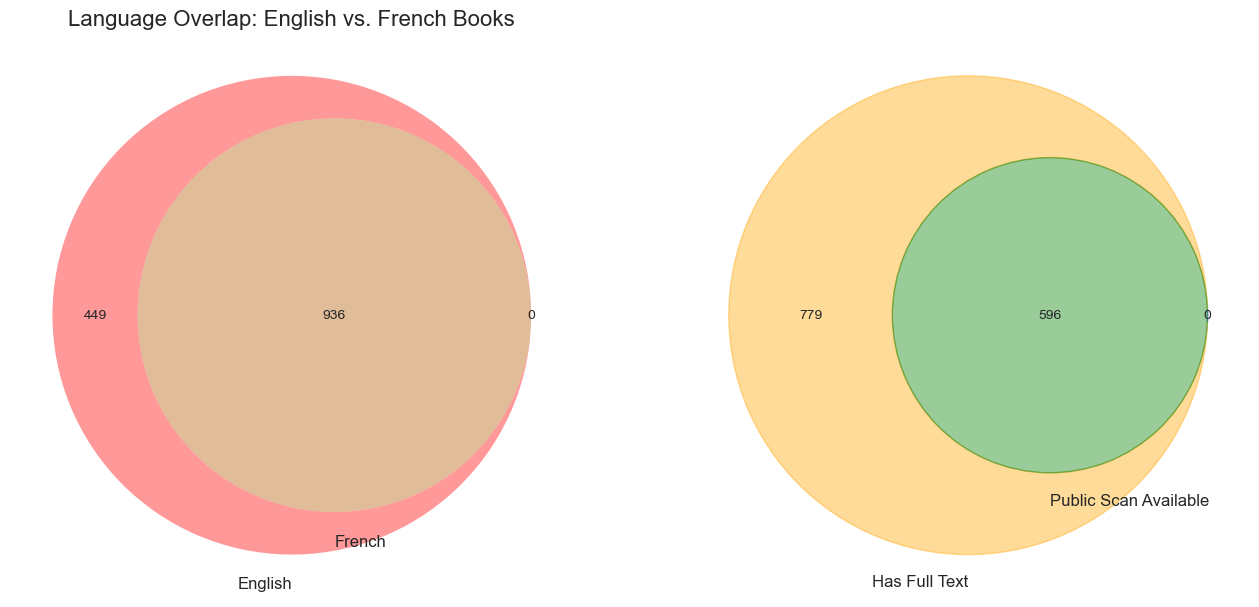

In [96]:
def check_language(lang_val, target_lang):
    try:
        # If it's a list string like "['eng', 'fre']", check inside
        if isinstance(lang_val, str) and '[' in lang_val:
            langs = ast.literal_eval(lang_val)
            return target_lang in langs
        return target_lang == lang_val
    except:
        return False


english_books = set(df[df['language'].apply(lambda x: check_language(x, 'eng'))].index)
french_books = set(df[df['language'].apply(lambda x: check_language(x, 'fre'))].index)


fulltext_books = set(df[df['has_fulltext'] == True].index)
public_scan_books = set(df[df['public_scan_b'] == True].index)


plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
venn2([english_books, french_books], set_labels=('English', 'French'))
plt.title('Language Overlap: English vs. French Books', fontsize=16)
plt.subplot(1, 2, 2)
v = venn2([fulltext_books, public_scan_books], set_labels=('Has Full Text', 'Public Scan Available'))
try:
    v.get_patch_by_id('10').set_color('orange')
    v.get_patch_by_id('01').set_color('blue')
    v.get_patch_by_id('11').set_color('green')
except:
    pass 
    plt.title('Feature Overlap: Full Text vs. Public Scan', fontsize=16)
plt.show()

### "How much do these distinct groups overlap?"
Here is a detailed breakdown of what this code does, what you will see, and the valuable insights you can gain from it.

### **Overview**
 **dashboard of two Venn Diagrams**. It is designed to analyze **relationships** between different categories in your dataset. Unlike bar charts that just show counts, Venn diagrams show **overlaps**, which helps you understand how different attributes of your books connect to each other.


### **1. The Left Diagram: Language Overlap (English vs. French)**

#### **What you will see:**
* **Two circles:** One representing all books tagged as **English**, and one for **French**.
* **The Intersection (Middle):** This represents books that contain **both** languages (e.g., bilingual editions, dictionaries, or books with metadata listing both languages).

#### **What you will understand (Insights):**
* **Collection Diversity:** You can instantly see which language dominates your library. If the "English" circle is huge and "French" is tiny, your dataset is primarily Anglophone.
* **Multilingualism:** The size of the middle section tells you about the *nature* of the books.
    * **No overlap?** The books are distinct monolingual editions.
    * **Large overlap?** You might have a lot of translated works stored together or language learning resources.

---

### **2. The Right Diagram: Feature Overlap (Full Text vs. Public Scan)**

#### **What you will see:**
* **Left Circle (Has Full Text):** Books that have searchable text content (you can Ctrl+F inside them).
* **Right Circle (Public Scan Available):** Books that have physical page images scanned and available to view.
* **Intersection:** Books that have **both** features (the ideal standard for a digital book).

#### **What you will understand (Insights):**
* **Data Quality Check:** This is the most critical part for a data analyst.
    * **Ideal Scenario:** You want a huge overlap. Usually, if a book is scanned (`Public Scan`), it undergoes OCR to create text (`Full Text`).
    * **"Scan Only" (Right side only):** These books are just images. The text hasn't been extracted yet, or the OCR failed. They are readable by humans but not by machines (harder to do NLP analysis on).
    * **"Full Text Only" (Left side only):** These might be modern "born-digital" ebooks (EPUBs) that never had a physical scan, or perhaps there is a metadata error where the text exists but the scan link is missing.

---

### **3. Technical & Code "Smartness"**
* **Handling Messy Data:** The function `check_language` is very smart. Data from scrapes often comes in messy formats (e.g., `['eng', 'fre']` as a string instead of a list). This code manually parses that string to ensure no book is missed just because of formatting errors.
* **Visual Clarity:** The code manually sets colors (`orange`, `blue`, `green`) for the second diagram. This makes it easier to distinguish between the groups visually compared to the default random colors.

### **Why is this important for your project?**
As a viewer, this visualization moves you beyond "How many books do I have?" to **"How usable are my books?"**
It tells you if your library is readable by machines (Full Text overlap) and if it bridges different languages (Language overlap).
Venn diagrams move beyond simple counts to show **relationships and consistency**. They help identify subsets of data that are "richer" (have multiple attributes) versus those that are single-attribute.

In [97]:
import matplotlib.pyplot as plt
import numpy as np

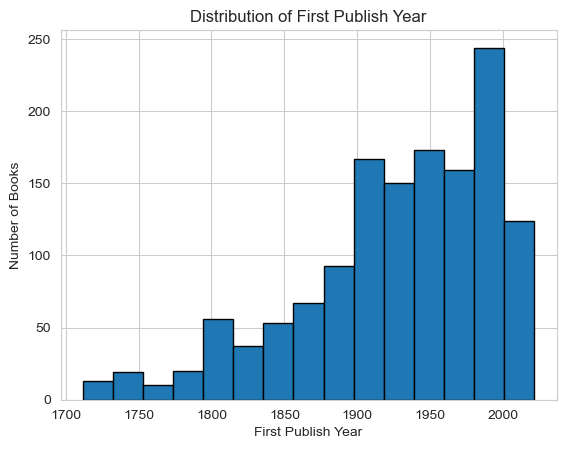

In [107]:
#Nevo

# 1. Histogram: Distribution of First Publish Year
plt.hist(df['first_publish_year'], bins=15, edgecolor='black')
plt.xlabel('First Publish Year')
plt.ylabel('Number of Books')
plt.title('Distribution of First Publish Year')
plt.show()


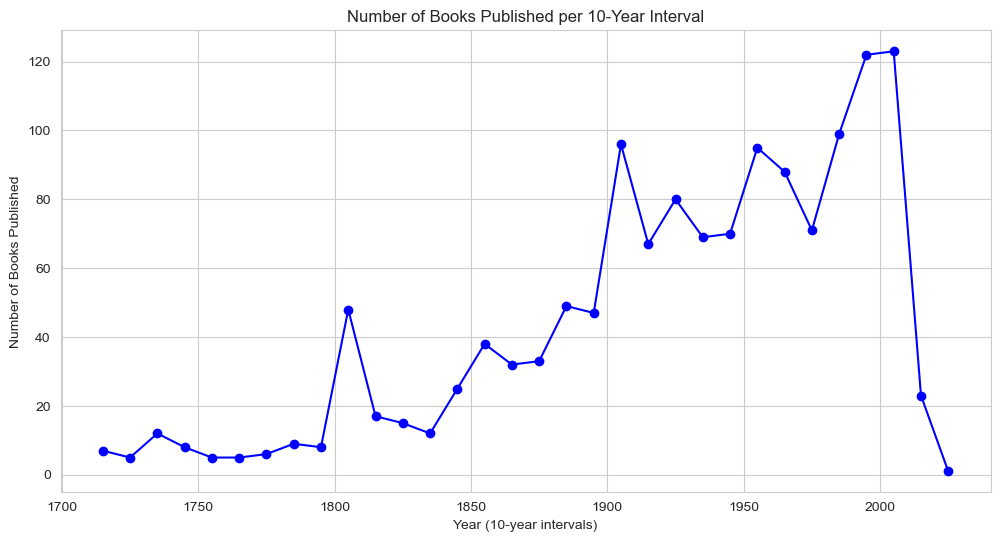

In [99]:
# 2. Line Plot: Number of Books Published per 10-Year Interval
min_year = df['first_publish_year'].min()
max_year = df['first_publish_year'].max()

bins = np.arange(min_year - (min_year % 10), max_year + 10, 10)

counts, edges = np.histogram(df['first_publish_year'], bins=bins)

bin_centers = edges[:-1] + 5

plt.figure(figsize=(12,6))
plt.plot(bin_centers, counts, marker='o', linestyle='-', color='blue')
plt.xlabel('Year (10-year intervals)')
plt.ylabel('Number of Books Published')
plt.title('Number of Books Published per 10-Year Interval')
plt.grid(True)
plt.show()

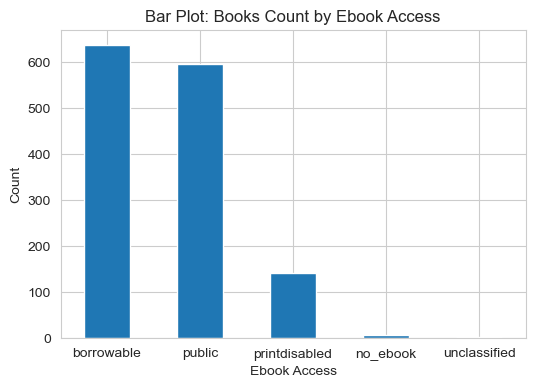

In [100]:
# 3. Bar Plot: Books Count by Ebook Access
plt.figure(figsize=(6,4))
df['ebook_access'].value_counts().plot(kind='bar')
plt.xlabel('Ebook Access')
plt.ylabel('Count')
plt.title('Bar Plot: Books Count by Ebook Access')
plt.xticks(rotation=0)
plt.show()


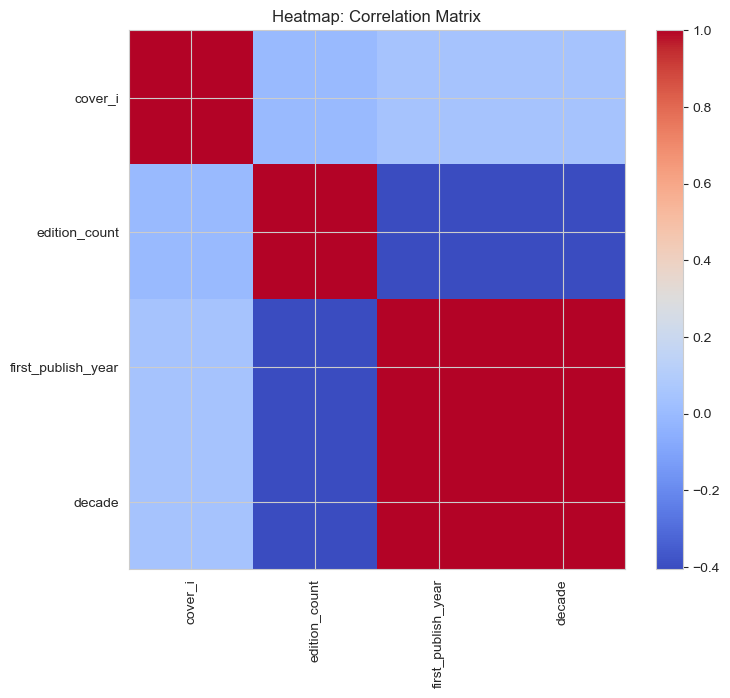

                     cover_i  edition_count  first_publish_year    decade
cover_i             1.000000      -0.002256            0.049206  0.049757
edition_count      -0.002256       1.000000           -0.405739 -0.405345
first_publish_year  0.049206      -0.405739            1.000000  0.998965
decade              0.049757      -0.405345            0.998965  1.000000


In [101]:
# 4. Heatmap: Correlation Matrix
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(8, 7))
plt.imshow(corr_matrix, aspect='auto', cmap='coolwarm')
plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix)), corr_matrix.columns)
plt.colorbar()
plt.title('Heatmap: Correlation Matrix')
plt.show()
print(corr_matrix)



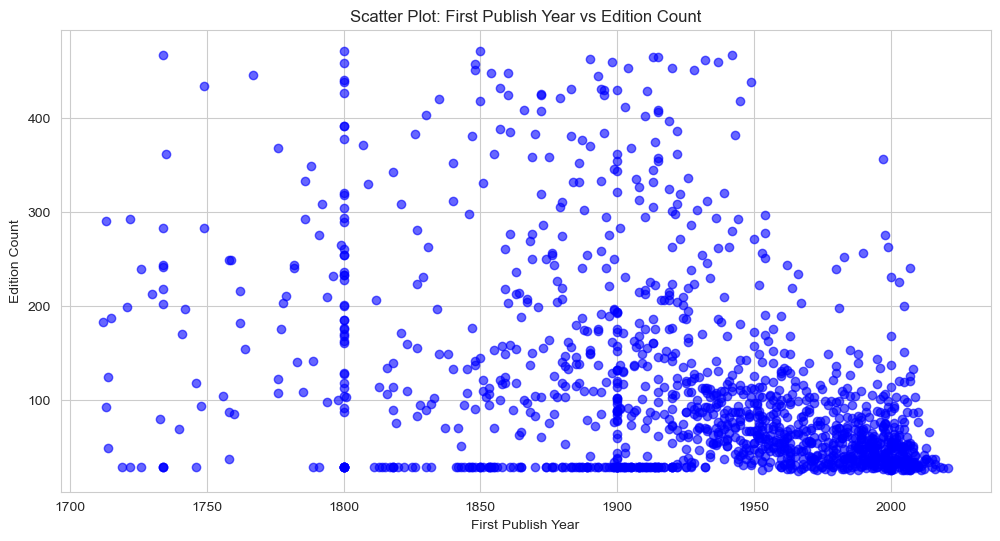

In [102]:
# 5. Scatter Plot: First Publish Year vs Edition Count
plt.figure(figsize=(12,6))
plt.scatter(df['first_publish_year'], df['edition_count'], alpha=0.6, color='blue')
plt.xlabel('First Publish Year')
plt.ylabel('Edition Count')
plt.title('Scatter Plot: First Publish Year vs Edition Count')
plt.show()

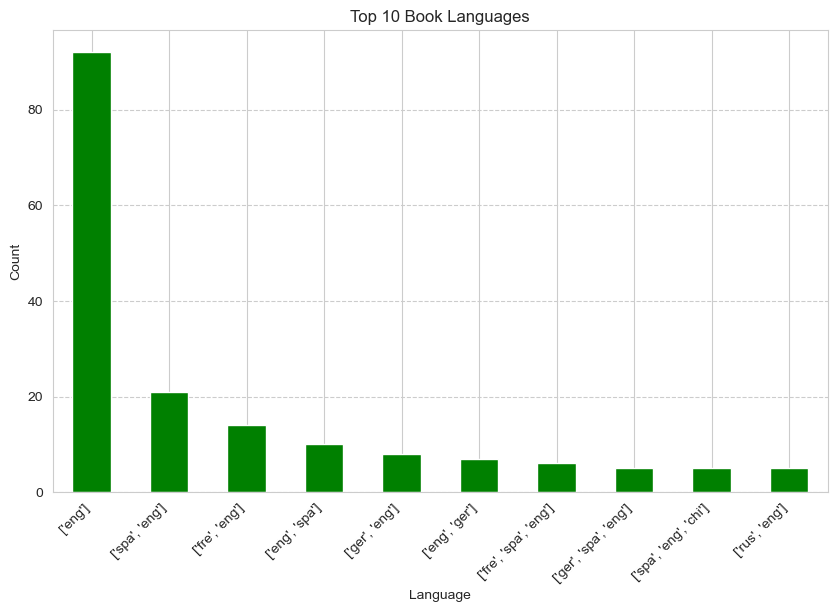

In [103]:
# 6. Bar Plot: Top 10 Book Languages
plt.figure(figsize=(10, 6))
df['language'].value_counts().head(10).plot(kind='bar', color='green')
plt.xlabel('Language')
plt.ylabel('Count')
plt.title('Top 10 Book Languages')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.show()

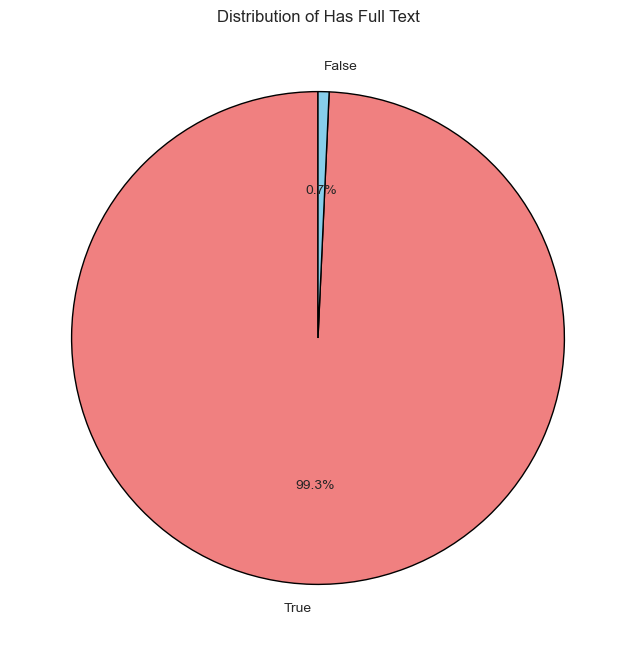

In [104]:
# 7. Pie Chart: Distribution of Has Full Text
plt.figure(figsize=(8, 8))
df['has_fulltext'].astype(str).value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'skyblue'], wedgeprops={'edgecolor': 'black'})
plt.ylabel('')
plt.title('Distribution of Has Full Text')
plt.show()

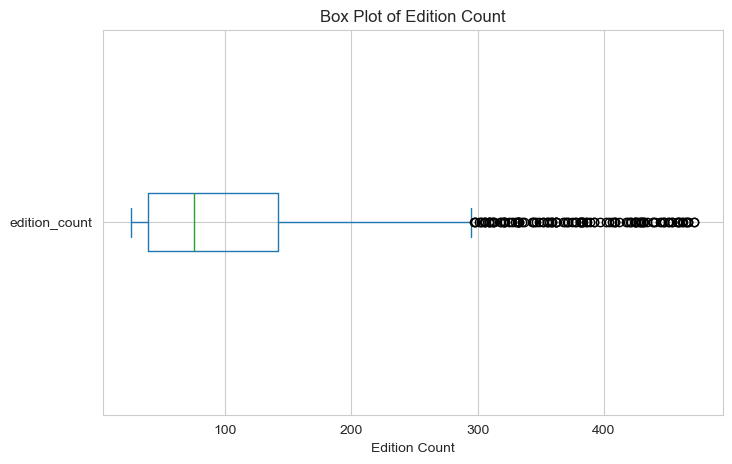

In [105]:
# 8. Box Plot: Edition Count (Outliers)
plt.figure(figsize=(8, 5))
df['edition_count'].dropna().plot(kind='box', vert=False)
plt.xlabel('Edition Count')
plt.title('Box Plot of Edition Count')
plt.show()

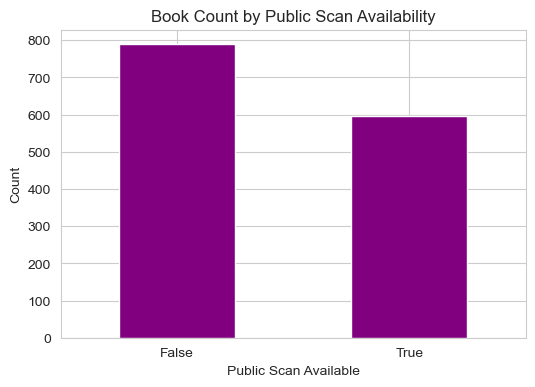

In [106]:
# 9. Bar Plot: Book Count by Public Scan Availability
plt.figure(figsize=(6, 4))
df['public_scan_b'].value_counts().plot(kind='bar', color='purple')
plt.xlabel('Public Scan Available')
plt.ylabel('Count')
plt.title('Book Count by Public Scan Availability')
plt.xticks(rotation=0)
plt.show()

### Project By :
*Marym el sayed*: 

*Malak Helmy*:

*Mariana Gamil*:

*Malak Attwan*: 2401249952

*Nervana Mohammed*: 